# Übung

Build a model to predict Fashion MNIST
- Preparation
- Building
- Training
- Prediction
- Confusion Matrix
- Saving the model

Delivery as
1. NoteBook

## 📦 Bibliotheken importieren

In [1]:
import numpy as np
import tensorflow as tf
from keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical # para el one-hot-encoding
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import keras
import matplotlib.pyplot as plt

## 📊 Daten laden

In [2]:
# Define label names for Fashion MNIST classes
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Load and preprocess the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

def translate_to_names(index: int):
    return class_names[index]

## 👀 Visualize
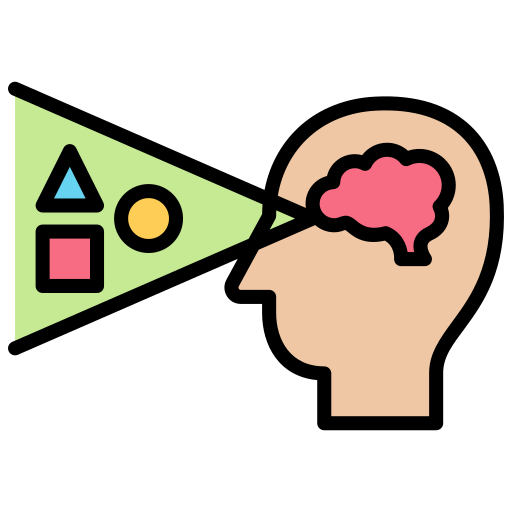

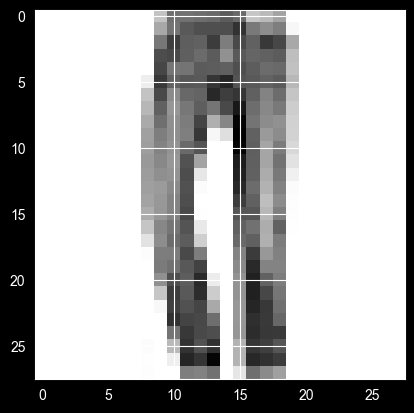

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [3]:
IMAGE_INDEX = 1500
plt.imshow(x_train[IMAGE_INDEX], cmap=plt.cm.binary)
plt.show()

y_train[IMAGE_INDEX]
x_train[1]

## 🔀 Train/Test Split

In [4]:
# Normalizar
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [5]:
# Agregar dimensión del canal
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
# Guardar copia de labels enteros para matriz de confusión
y_test_int = y_test.copy()

In [7]:
# One-hot para labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10) # y_test ya no es un entero de clase, sino un vector de 10 posiciones.

In [8]:
y_train[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
x_train[1]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00392157],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.16078432],
        [0.7372549 ],
        [0.40392157],
        [0.21176471],
        [0.1882353 ],
        [0.16862746],
        [0.34117648],
        [0.65882355],
        [0.52156866],
        [0.0627451 ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.00392157],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.19215687],
        [0.53333336],
        [0.85882354],
        [0.84705883],
        [0.89411765],
        [0.9254902 ],
        [1.        ],
        [1.        ],
        [1.        ],
        [1.        ],
        

## ⚖️ Feature-Skalierung **(no needed here)**

In [10]:
"""scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)"""

'scaler = StandardScaler()\nX_train = scaler.fit_transform(x_train)\nX_test = scaler.transform(x_test)'

## 🧠 Create Modell

In [11]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),


    # Bloque 1
    layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque 2
    layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque 3
    layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Cabeza densa
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

## 📒 Summary

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 437,098 (1.67 MB)

 Trainable params: 436,202 (1.66 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
from keras.optimizers import SGD

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

## 🚀 Training

In [14]:
version = model.fit(x_train, y_train, epochs=25, shuffle=True, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7645 - loss: 0.6418 - val_accuracy: 0.8316 - val_loss: 0.4408
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8396 - loss: 0.4417 - val_accuracy: 0.8730 - val_loss: 0.3455
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8606 - loss: 0.3834 - val_accuracy: 0.8692 - val_loss: 0.3716
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8731 - loss: 0.3501 - val_accuracy: 0.8880 - val_loss: 0.3107
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8815 - loss: 0.3248 - val_accuracy: 0.8827 - val_loss: 0.3144
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8889 - loss: 0.3084 - val_accuracy: 0.8946 - val_loss: 0.2889
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8962 - loss: 0.2873 - val_accuracy: 0.8967 - val_loss: 0.2793
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8993 -

## 📈 Plot: Accuracy & Loss

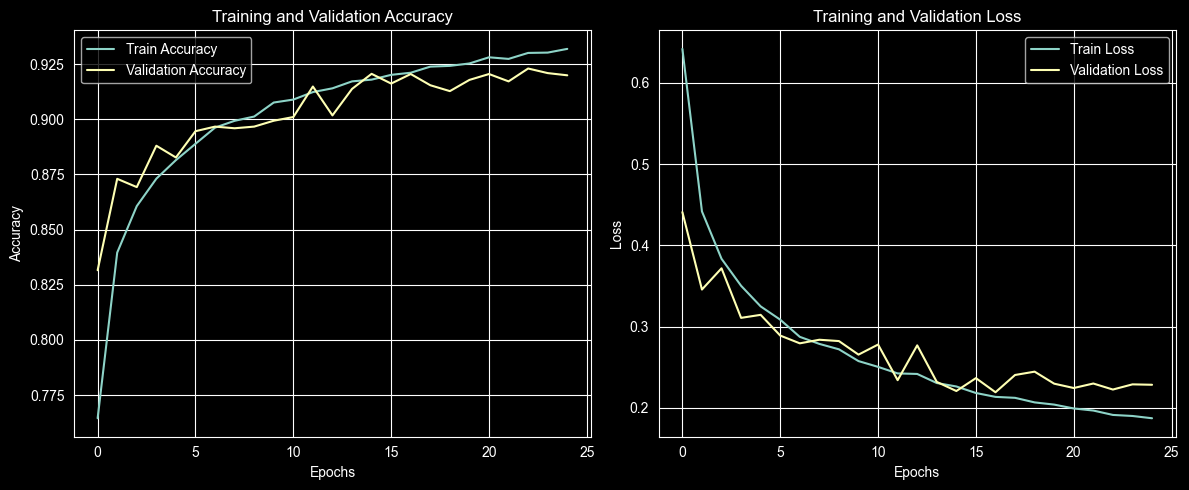

In [15]:
plt.figure(figsize=(12, 5))

# Accuracy (<-)
plt.subplot(1, 2, 1) # plt.subplot(n_filas, n_columnas, índice)
plt.plot(version.history["accuracy"], label="Train Accuracy")
plt.plot(version.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss (->)
plt.subplot(1, 2, 2)
plt.plot(version.history["loss"], label="Train Loss")
plt.plot(version.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Predictions
predict = model.predict(x_test)
pred_classes = np.argmax(predict, axis=1)
print("Distribución de clases predichas:", np.unique(pred_classes, return_counts=True))

# Ground truth en clases enteras
y_true = np.argmax(y_test, axis=1)
print(np.unique(y_true, return_counts=True))
print("Pred classes:", np.unique(pred_classes, return_counts=True))
print("True classes:", np.unique(y_true, return_counts=True))
print(predict[:5])


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Distribución de clases predichas: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1056,  990,  946,  999, 1062, 1014,  944, 1041, 1001,  947]))
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
Pred classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1056,  990,  946,  999, 1062, 1014,  944, 1041, 1001,  947]))
True classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
[[3.9406856e-08 1.4357099e-12 1.1148245e-09 4.1990281e-10 2.1292164e-08
  9.1973219e-05 7.6677644e-08 1.9869199e-03 1.9481112e-08 9.9792105e-01]
 [3.9987699e-06 3.7726701e-12 9.9916089e-01 8.6001695e-09 1.5163385e-04
  6.5977790e-13 6.8343076e-04 1.8982671e-15 1.6870679e-09 1.2159226e-15]
 [9.4545790e-13 1.0000000e+00 7.1047355e-16 2.2469727e-11 7.5749377e-15
  3.4214155e-20 8.9858974e-14 9.3699396e-23 1.5955080e-14 1.4556776e-18]
 [3.7055485e-12 1.0000000e

In [17]:
y_test[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [18]:
predict[1]

array([3.9987699e-06, 3.7726701e-12, 9.9916089e-01, 8.6001695e-09,
       1.5163385e-04, 6.5977790e-13, 6.8343076e-04, 1.8982671e-15,
       1.6870679e-09, 1.2159226e-15], dtype=float32)

## 📲 Confusion Matrix

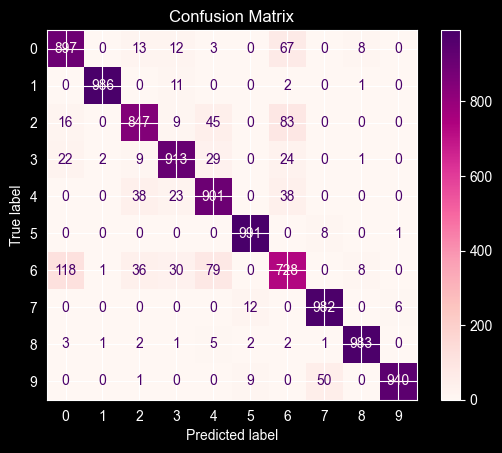

In [19]:
cm = confusion_matrix(y_test_int, pred_classes)
display = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
display.plot(cmap="RdPu", values_format="d")
plt.title("Confusion Matrix")
plt.show()


In [20]:
print("predict shape:", predict.shape)
print("primera predicción:", predict[0])
print("clase predicha primera muestra:", np.argmax(predict[0]))
print("distribución de clases predichas:", np.unique(pred_classes, return_counts=True))

predict shape: (10000, 10)
primera predicción: [3.9406856e-08 1.4357099e-12 1.1148245e-09 4.1990281e-10 2.1292164e-08
 9.1973219e-05 7.6677644e-08 1.9869199e-03 1.9481112e-08 9.9792105e-01]
clase predicha primera muestra: 9
distribución de clases predichas: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1056,  990,  946,  999, 1062, 1014,  944, 1041, 1001,  947]))


## ✅ Evaluate

In [21]:
from sklearn.metrics import classification_report

eval_loss, eval_acc = model.evaluate(x_test, y_test)
f1 = classification_report(y_true, pred_classes)
print("*-*" * 10)
print(f"Accuracy: {eval_acc}")
print("*-*" * 10)
print(f"F1: {f1}")
print("*-*" * 10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9168 - loss: 0.2307
*-**-**-**-**-**-**-**-**-**-*
Accuracy: 0.9168000221252441
*-**-**-**-**-**-**-**-**-**-*


In [22]:
print(np.unique(np.argmax(y_train, axis=1), return_counts=True))
print(np.unique(pred_classes, return_counts=True))
print(x_train.shape)
print(y_train.shape)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1056,  990,  946,  999, 1062, 1014,  944, 1041, 1001,  947]))
(60000, 28, 28, 1)
(60000, 10)


In [23]:
indices = np.where((y_test == 0) & (pred_classes == 6))[0]
print(f"Cantidad de errores 5→3: {len(indices)}")
for i in indices[:10]:  # muestra los primeros 10
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {translate_to_names(y_test[i])} | Predicted: {translate_to_names(pred_classes[i])}")
    plt.show()

ValueError: operands could not be broadcast together with shapes (10000,10) (10000,) 

In [ ]:
indices_1 = np.where((y_test == 4) & (pred_classes == 2))[0]
print(f"Cantidad de errores 4→2: {len(indices)}")
for i in indices_1[:10]:  # muestra los primeros 10
    plt.imshow(x_test[i].reshape(28, 28), cmap='grey')
    plt.title(f"Real: {translate_to_names(y_test[i])} | Predicted: {translate_to_names(pred_classes[i])}")
    plt.show()

# Save Model

In [ ]:
model.save("fashion_model.keras")

# Load Model

In [ ]:
model_2 = keras.models.load_model("fashion_model.keras")
model_2.summary()

# Save weights

In [ ]:
model.save_weights("fashion_model.keras.weights.h5")

In [ ]:
# crear la misma estructura del Model sin compilar ni entrenar
ACTIVATION_FUNCTION_HIDDEN_1 = 'sigmoid'
ACTIVATION_FUNCTION_HIDDEN_2 = 'relu'
ACTIVATION_FUNCTION_OUTPUT = 'softmax'

model_weights = models.Sequential([
    # 0 INPUT LAYER (primera capa -izq-)
    keras.Input(shape=(784,)),


    # 1 hidden layer (capa oculta)
    #        q tantas neuronas, que tipo de activacion,
    keras.layers.Dense(512, activation=ACTIVATION_FUNCTION_HIDDEN_1),

    # 2 hidden layer (capa oculta)
    keras.layers.Dense(128, activation=ACTIVATION_FUNCTION_HIDDEN_1),


    # 3 output layer (capa de salida)
    keras.layers.Dense(10, activation=ACTIVATION_FUNCTION_HIDDEN_1),
])


In [ ]:
# Load weights
model_weights.load_weights("fashion_model.keras.weights.h5")

# Callbacks

In [ ]:
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint

my_callbacks_list = [
    EarlyStopping(monitor='val_loss', min_delta=0.00001, patience=3, verbose=0, mode='auto'),
    CSVLogger('logs/fashion_training.log', append=True),
    ModelCheckpoint(filepath="./models/model.{epoch:02d}-{val_loss:.2f}.keras",)
]

# Train Model using Callbacks

In [ ]:
from tensorflow.keras.utils import to_categorical
history = model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2, callbacks=my_callbacks_list)